# Procesamiento Digital de Imágenes
## Guía de Trabajos Prácticos 7 — Nociones de Segmentación
**FICH, UNL — Ingeniería Informática**

## Ejercicio 1: Detección de bordes

Imágenes cargadas correctamente


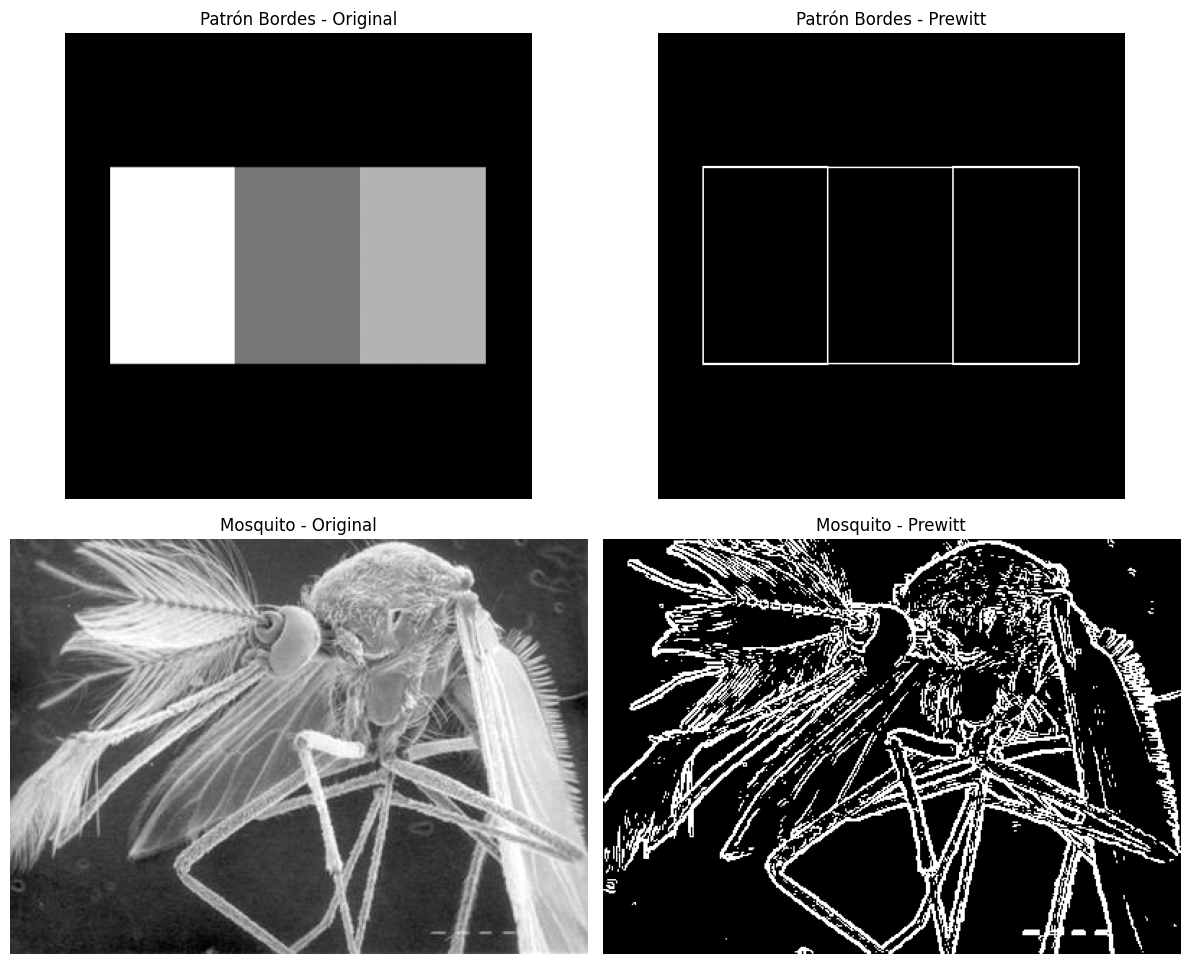

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider, IntRangeSlider
import ipywidgets as widgets

plt.rcParams['figure.figsize'] = (12, 8)
%matplotlib inline

# Carga de imágenes
img_bordes = cv2.imread('patron_bordes.jpg', cv2.IMREAD_GRAYSCALE)
img_mosquito = cv2.imread('mosquito.jpg', cv2.IMREAD_GRAYSCALE)

print("Imágenes cargadas correctamente")

def prewitt_edge(img):
    kernel_x = np.array([[ -1, 0, 1],
                         [ -1, 0, 1],
                         [ -1, 0, 1]], dtype=np.float32)
    kernel_y = np.array([[ -1,-1,-1],
                         [  0, 0, 0],
                         [  1, 1, 1]], dtype=np.float32)
    
    grad_x = cv2.filter2D(img, cv2.CV_32F, kernel_x)
    grad_y = cv2.filter2D(img, cv2.CV_32F, kernel_y)
    grad = np.sqrt(grad_x**2 + grad_y**2)
    grad = cv2.normalize(grad, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, binary = cv2.threshold(grad, 50, 255, cv2.THRESH_BINARY)
    return binary


plt.figure(figsize=(12, 10))
# --- Fila 1: Imagen Patrón de Bordes ---
plt.subplot(2, 2, 1)
plt.imshow(img_bordes, cmap='gray')
plt.title('Patrón Bordes - Original')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(prewitt_edge(img_bordes), cmap='gray')
plt.title('Patrón Bordes - Prewitt')
plt.axis('off')

# --- Fila 2: Imagen Mosquito ---
plt.subplot(2, 2, 3) 
plt.imshow(img_mosquito, cmap='gray')
plt.title('Mosquito - Original')
plt.axis('off')

plt.subplot(2, 2, 4) 
plt.imshow(prewitt_edge(img_mosquito), cmap='gray')
plt.title('Mosquito - Prewitt')
plt.axis('off')

plt.tight_layout() 
plt.show()

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, widgets

# Asegurate de que img_bordes y img_mosquito estén cargadas en la celda anterior

def sobel_interact(imagen_nombre, dx, dy, ksize_val, ddepth_name):
    # 1. Mapeo de selecciones del widget a las variables reales
    diccionario_imagenes = {'Patrón Bordes': img_bordes, 'Mosquito': img_mosquito}
    img_analisis = diccionario_imagenes[imagen_nombre]
    
    diccionario_ddepth = {'CV_8U': cv2.CV_8U, 'CV_64F': cv2.CV_64F}
    ddepth = diccionario_ddepth[ddepth_name]
    
    # 2. Controles de seguridad para evitar que OpenCV tire error (crash)
    if dx == 0 and dy == 0:
        print("Error: dx y dy no pueden ser 0 al mismo tiempo para calcular Sobel.")
        return
        
    if ksize_val == -1 and (dx + dy != 1):
        print("Error: El filtro Scharr (ksize=-1) solo admite (dx=1, dy=0) o (dx=0, dy=1).")
        return

    # 3. Aplicación del filtro
    sobel = cv2.Sobel(img_analisis, ddepth, dx, dy, ksize=ksize_val)
    
    # cv2.convertScaleAbs toma el valor absoluto (fundamental cuando usamos CV_64F)
    sobel_abs = cv2.convertScaleAbs(sobel)

    # 4. Visualización
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img_analisis, cmap='gray')
    plt.title(f'Original: {imagen_nombre}')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(sobel_abs, cmap='gray')
    titulo_ksize = "Scharr" if ksize_val == -1 else ksize_val
    plt.title(f'Sobel -> dx={dx}, dy={dy}, ksize={titulo_ksize}, {ddepth_name}')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Creación de la interfaz interactiva
interact(sobel_interact, 
         imagen_nombre=widgets.Dropdown(options=['Patrón Bordes', 'Mosquito'], value='Patrón Bordes', description='Imagen:'),
         dx=widgets.IntSlider(min=0, max=2, step=1, value=1, description='dx:'),
         dy=widgets.IntSlider(min=0, max=2, step=1, value=0, description='dy:'),
         ksize_val=widgets.Dropdown(options=[('3', 3), ('5', 5), ('7', 7), ('Scharr (-1)', -1)], value=3, description='ksize:'),
         ddepth_name=widgets.Dropdown(options=['CV_8U', 'CV_64F'], value='CV_64F', description='ddepth:'))

interactive(children=(Dropdown(description='Imagen:', options=('Patrón Bordes', 'Mosquito'), value='Patrón Bor…

<function __main__.sobel_interact(imagen_nombre, dx, dy, ksize_val, ddepth_name)>

In [3]:
def laplacian_interact(imagen_nombre, ksize_val, ddepth_name):
    # 1. Mapeo de variables
    diccionario_imagenes = {'Patrón Bordes': img_bordes, 'Mosquito': img_mosquito}
    img_analisis = diccionario_imagenes[imagen_nombre]
    
    diccionario_ddepth = {'CV_8U': cv2.CV_8U, 'CV_64F': cv2.CV_64F}
    ddepth = diccionario_ddepth[ddepth_name]
    
    # 2. Aplicación del filtro Laplaciano (2da derivada)
    # A diferencia de Sobel, el Laplaciano calcula los bordes en todas 
    # las direcciones al mismo tiempo, por lo que no hay dx ni dy.
    laplacian = cv2.Laplacian(img_analisis, ddepth, ksize=ksize_val)
    
    # Tomamos el valor absoluto (crucial si usamos CV_64F)
    laplacian_abs = cv2.convertScaleAbs(laplacian)

    # 3. Visualización
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img_analisis, cmap='gray')
    plt.title(f'Original: {imagen_nombre}')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(laplacian_abs, cmap='gray')
    plt.title(f'Laplaciano -> ksize={ksize_val}, {ddepth_name}')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Creación de la interfaz interactiva
# ksize para Laplaciano debe ser un número impar y positivo (1, 3, 5, 7, etc.)
interact(laplacian_interact, 
         imagen_nombre=widgets.Dropdown(options=['Patrón Bordes', 'Mosquito'], value='Patrón Bordes', description='Imagen:'),
         ksize_val=widgets.Dropdown(options=[1, 3, 5, 7, 9, 11], value=3, description='ksize:'),
         ddepth_name=widgets.Dropdown(options=['CV_8U', 'CV_64F'], value='CV_64F', description='ddepth:'))

interactive(children=(Dropdown(description='Imagen:', options=('Patrón Bordes', 'Mosquito'), value='Patrón Bor…

<function __main__.laplacian_interact(imagen_nombre, ksize_val, ddepth_name)>

### Análisis del Filtro Laplaciano

Al analizar el Laplaciano (que calcula la segunda derivada espacial), estas son mis conclusiones principales:

* **Sensibilidad al ruido:** En la imagen sintética (`patron_bordes.jpg`) obtuve un resultado muy limpio.
* **Talla del filtro (`ksize`):** Al aumentar el tamaño de la máscara (de 3 a 5 o 7), los bordes resultantes se volvieron mucho más gruesos. Además, pude observar claramente el efecto de "doble línea" que se genera justo en el cruce por cero de la segunda derivada.
* **Tipos de datos (`ddepth`):** Comprobé que es indispensable procesar la imagen usando `CV_64F` y luego calcular el valor absoluto. Cuando intenté usar `CV_8U`, los gradientes negativos se truncaron a cero y perdí exactamente la mitad de la información visual de los bordes.

In [4]:
def canny_interact(imagen_nombre, t1, t2, aperture_size, l2_gradient):
    # 1. Mapeo de la imagen
    diccionario_imagenes = {'Patrón Bordes': img_bordes, 'Mosquito': img_mosquito}
    img_analisis = diccionario_imagenes[imagen_nombre]
    
    bordes_canny = cv2.Canny(img_analisis, 
                             threshold1=t1, 
                             threshold2=t2, 
                             apertureSize=aperture_size, 
                             L2gradient=l2_gradient)

    # 3. Visualización
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img_analisis, cmap='gray')
    plt.title(f'Original: {imagen_nombre}')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(bordes_canny, cmap='gray')
    titulo_canny = f'Canny -> t1={t1}, t2={t2}, aperture={aperture_size}, L2={l2_gradient}'
    plt.title(titulo_canny)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Creación de la interfaz interactiva
interact(canny_interact, 
         imagen_nombre=widgets.Dropdown(options=['Patrón Bordes', 'Mosquito'], value='Mosquito', description='Imagen:'),
         t1=widgets.IntSlider(min=0, max=500, step=5, value=50, description='Threshold 1:'),
         t2=widgets.IntSlider(min=0, max=500, step=5, value=150, description='Threshold 2:'),
         aperture_size=widgets.Dropdown(options=[3, 5, 7], value=3, description='Aperture:'),
         l2_gradient=widgets.Checkbox(value=False, description='L2gradient'))

interactive(children=(Dropdown(description='Imagen:', index=1, options=('Patrón Bordes', 'Mosquito'), value='M…

<function __main__.canny_interact(imagen_nombre, t1, t2, aperture_size, l2_gradient)>

Este algoritmo me dio los bordes más definidos. Al variar los parámetros en la interfaz interactiva, noté lo siguiente:

* **El parámetro `L2gradient`:** Al activarlo, Canny abandona la aproximación de Manhattan y calcula la magnitud del gradiente usando la norma Euclidiana exacta ($\sqrt{G_x^2 + G_y^2}$). Al hacer esto, noté que la magnitud total disminuye levemente, lo que provocó que algunos bordes débiles desaparecieran hasta que reajusté los umbrales. Es una métrica más precisa, pero exige recalibrar.
* **Umbrales por histéresis (`t1` y `t2`):** Al fijar un `t2` alto, logré aislar los bordes más fuertes y seguros. Lo más revelador fue jugar con `t1` (el umbral inferior): al subirlo y bajarlo, pude ver literalmente cómo los bordes débiles se ramificaban, conectándose o desconectándose de los bordes fuertes.
* **Tamaño de apertura (`apertureSize`):** Al incrementar el tamaño del filtro de Sobel interno (pasando de 3 a 5), los valores numéricos del gradiente se dispararon. Tuve que subir los umbrales `t1` y `t2` casi al límite superior para evitar saturar la imagen con detecciones falsas.

In [5]:
def aplicar_ruido_y_bordes(tipo_ruido, intensidad, gris_impulsivo, detector):
    img_orig = img_mosquito.copy()
    
    # --- 1. Generación de Ruido ---
    if tipo_ruido == 'Impulsivo Unimodal':
        # intensidad es la probabilidad (0 a 1)
        prob = intensidad / 100.0
        ruido = np.random.rand(*img_orig.shape)
        img_ruidosa = img_orig.copy()
        img_ruidosa[ruido < prob] = gris_impulsivo
        
    elif tipo_ruido == 'Gaussiano':
        # intensidad es el desvío estándar (sigma)
        gauss = np.random.normal(0, intensidad, img_orig.shape)
        img_ruidosa = np.clip(img_orig + gauss, 0, 255).astype(np.uint8)

    # --- 2. Detección de Bordes ---
    if detector == 'Sobel':
        grad_x = cv2.Sobel(img_ruidosa, cv2.CV_64F, 1, 0, ksize=3)
        grad_y = cv2.Sobel(img_ruidosa, cv2.CV_64F, 0, 1, ksize=3)
        borde = cv2.addWeighted(cv2.convertScaleAbs(grad_x), 0.5, cv2.convertScaleAbs(grad_y), 0.5, 0)
    elif detector == 'Laplaciano':
        lap = cv2.Laplacian(img_ruidosa, cv2.CV_64F, ksize=3)
        borde = cv2.convertScaleAbs(lap)
    elif detector == 'Canny':
        borde = cv2.Canny(img_ruidosa, 50, 150) # Umbrales fijos para comparar
        
    # --- 3. Visualización ---
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1); plt.imshow(img_orig, cmap='gray')
    plt.title('Original'); plt.axis('off')
    
    plt.subplot(1, 3, 2); plt.imshow(img_ruidosa, cmap='gray')
    plt.title(f'Ruido: {tipo_ruido}'); plt.axis('off')
    
    plt.subplot(1, 3, 3); plt.imshow(borde, cmap='gray')
    plt.title(f'Detector: {detector}'); plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Interfaz interactiva
interact(aplicar_ruido_y_bordes, 
         tipo_ruido=widgets.Dropdown(options=['Impulsivo Unimodal', 'Gaussiano'], value='Gaussiano', description='Tipo Ruido:'),
         intensidad=widgets.IntSlider(min=0, max=100, step=5, value=20, description='Intensidad (Prob / Desvío):', style={'description_width': 'initial'}),
         gris_impulsivo=widgets.IntSlider(min=0, max=255, step=1, value=255, description='Gris Impulsivo:'),
         detector=widgets.Dropdown(options=['Sobel', 'Laplaciano', 'Canny'], value='Sobel', description='Detector:'))

interactive(children=(Dropdown(description='Tipo Ruido:', index=1, options=('Impulsivo Unimodal', 'Gaussiano')…

<function __main__.aplicar_ruido_y_bordes(tipo_ruido, intensidad, gris_impulsivo, detector)>

### Respuestas de la guía: Análisis con ruido

* **¿En qué zonas (debido a qué) funciona mejor y en cuáles no?**
  Funciona mejor en los contornos principales del mosquito debido al alto contraste entre el bicho y el fondo. Falla en las zonas internas (texturas) y en el fondo liso, porque el ruido crea gradientes falsos que el detector interpreta como bordes.

* **¿Qué sucede con el ruido?**
  Al estar basados en derivadas espaciales, los métodos amplifican las altas frecuencias (cambios bruscos). El ruido genera variaciones altísimas de un píxel a otro, llenando la imagen resultante de "basura" o falsos positivos (especialmente el Laplaciano, por usar la segunda derivada).

* **¿Con qué tipo de imágenes sacaría mejor provecho de los métodos?**
  Con imágenes limpias, de alto contraste, buena iluminación y con poco nivel de ruido. 

* **¿Qué tipo de preprocesamientos, de los que ya conoce, se le ocurren que serían útiles?**
  Es obligatorio aplicar un filtro de suavizado espacial antes de detectar bordes:
  1. **Filtro Gaussiano:** Para eliminar el ruido Gaussiano (como hace internamente el método de Canny).
  2. **Filtro de Mediana:** Para eliminar el ruido impulsivo sin desenfocar los bordes reales de la imagen.

## Ejercicio 2 Transformada de Hough

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, widgets

def hough_interact(threshold_votos, rango_angulos):
    img_orig = img_bordes.copy()
    
    # 1. Preprocesamiento: Hough necesita una imagen binaria (bordes)
    img_bordes_canny = cv2.Canny(img_orig, 50, 150)
    
    # Imagen a color para poder dibujar las líneas rojas arriba
    img_resultado = cv2.cvtColor(img_orig, cv2.COLOR_GRAY2BGR)
    
    # 2. Conversión del rango de ángulos de Grados a Radianes
    min_theta = np.deg2rad(rango_angulos[0])
    max_theta = np.deg2rad(rango_angulos[1])
    
    # 3. Transformada de Hough Clásica
    # rho = 1 pixel de resolución, theta = 1 grado (en radianes) de resolución
    lineas = cv2.HoughLines(img_bordes_canny, 
                            rho=1, 
                            theta=np.pi/180, 
                            threshold=threshold_votos, 
                            min_theta=min_theta, 
                            max_theta=max_theta)
    
    # 4. Dibujar las líneas
    # cv2.HoughLines devuelve una lista de pares [rho, theta]
    if lineas is not None:
        for linea in lineas:
            rho, theta = linea[0]
            
            # Matemática para convertir coordenadas polares a cartesianas y estirar la línea
            a = np.cos(theta)
            b = np.sin(theta)
            x0 = a * rho
            y0 = b * rho
            
            x1 = int(x0 + 1000 * (-b))
            y1 = int(y0 + 1000 * (a))
            x2 = int(x0 - 1000 * (-b))
            y2 = int(y0 - 1000 * (a))
            
            # Dibujamos la línea en color rojo, grosor 2
            cv2.line(img_resultado, (x1, y1), (x2, y2), (0, 0, 255), 2)
            
    # 5. Visualización
    plt.figure(figsize=(15, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img_bordes_canny, cmap='gray')
    plt.title('Preproceso: Bordes Canny')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    # Convertimos de BGR (OpenCV) a RGB (Matplotlib)
    plt.imshow(cv2.cvtColor(img_resultado, cv2.COLOR_BGR2RGB))
    cantidad_lineas = len(lineas) if lineas is not None else 0
    plt.title(f'Transformada de Hough ({cantidad_lineas} líneas detectadas)')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Interfaz interactiva
interact(hough_interact,
         threshold_votos=widgets.IntSlider(min=10, max=300, step=10, value=100, description='Umbral (Votos):'),
         rango_angulos=widgets.IntRangeSlider(value=[0, 180], min=0, max=180, step=1, description='Ángulos (°):'))

interactive(children=(IntSlider(value=100, description='Umbral (Votos):', max=300, min=10, step=10), IntRangeS…

<function __main__.hough_interact(threshold_votos, rango_angulos)>

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, widgets

img_letras1 = cv2.imread('letras1.tif', cv2.IMREAD_GRAYSCALE)
img_letras2 = cv2.imread('letras2.tif', cv2.IMREAD_GRAYSCALE)
img_snowman = cv2.imread('snowman.png', cv2.IMREAD_GRAYSCALE)
img_building = cv2.imread('building.jpg', cv2.IMREAD_GRAYSCALE)

# Para que el código funcione sin errores acá, armá tu diccionario con las imágenes que tengas cargadas:
diccionario_hough = {
    'Letras 1': img_letras1, # Reemplazá con tus variables
    'Letras 2': img_letras2,
    'Snowman': img_snowman,
    'Building': img_building
}

def hough_prob_interact(nombre_img, threshold_votos, min_length, max_gap):
    img_orig = diccionario_hough[nombre_img]
    
    # 1. Preprocesamiento: Canny para obtener los bordes
    img_bordes_canny = cv2.Canny(img_orig, 50, 150)
    
    # Imagen a color para dibujar los segmentos detectados
    img_resultado = cv2.cvtColor(img_orig, cv2.COLOR_GRAY2BGR)
    
    # 2. Transformada de Hough Probabilística
    # Devuelve segmentos finitos: [x1, y1, x2, y2]
    lineas_prob = cv2.HoughLinesP(img_bordes_canny, 
                                  rho=1, 
                                  theta=np.pi/180, 
                                  threshold=threshold_votos, 
                                  minLineLength=min_length, 
                                  maxLineGap=max_gap)
    
    # 3. Dibujar las líneas
    # A diferencia de Hough clásica, acá nos dan los puntos exactos de inicio y fin.
    if lineas_prob is not None:
        for linea in lineas_prob:
            x1, y1, x2, y2 = linea[0]
            cv2.line(img_resultado, (x1, y1), (x2, y2), (0, 255, 0), 2) # Líneas verdes
            
    # 4. Visualización
    plt.figure(figsize=(15, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img_bordes_canny, cmap='gray')
    plt.title('Bordes Canny')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(img_resultado, cv2.COLOR_BGR2RGB))
    cantidad_lineas = len(lineas_prob) if lineas_prob is not None else 0
    plt.title(f'Hough Probabilística ({cantidad_lineas} segmentos)')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Interfaz interactiva
interact(hough_prob_interact,
         nombre_img=widgets.Dropdown(options=list(diccionario_hough.keys()), value='Building', description='Imagen:'),
         threshold_votos=widgets.IntSlider(min=10, max=300, step=5, value=50, description='Umbral:'),
         min_length=widgets.IntSlider(min=1, max=200, step=5, value=20, description='minLineLength:', style={'description_width': 'initial'}),
         max_gap=widgets.IntSlider(min=1, max=50, step=1, value=5, description='maxLineGap:'))

interactive(children=(Dropdown(description='Imagen:', index=3, options=('Letras 1', 'Letras 2', 'Snowman', 'Bu…

<function __main__.hough_prob_interact(nombre_img, threshold_votos, min_length, max_gap)>

### Análisis de la Transformada de Hough: Clásica (SHT) vs Probabilística (PHT)

Tras aplicar ambas transformadas a las distintas imágenes:

**1. Formato de salida y representación matemática:**
*   **Hough Clásica (`cv.HoughLines`):** Devuelve un arreglo matemático de coordenadas polares `[rho, theta]`. Esto define líneas matemáticas "infinitas" que atraviesan toda la imagen.
*   **Hough Probabilística (`cv.HoughLinesP`):** Devuelve directamente los puntos cartesianos de inicio y fin del segmento `[x1, y1, x2, y2]`. 

**2. Diferencias principales, ventajas y desventajas:**
*   **Velocidad:** La versión Probabilística es muchísimo más rápida porque no evalúa todos los píxeles de borde, sino una muestra aleatoria suficiente para la detección.
*   **Fragmentación:** La desventaja de la probabilística es que si los parámetros `minLineLength` (largo mínimo) y `maxLineGap` (hueco máximo permitido entre puntos) no están bien ajustados, una misma línea recta puede fragmentarse en varios segmentos separados.

**3. ¿Cuándo utilizaría uno u otro?**
*   **Hough Clásico:** Lo usaría cuando necesito detectar líneas globales de referencia en una imagen limpia (ej. la línea del horizonte, renglones enteros de una hoja, o la perspectiva general de una calle). 
*   **Hough Probabilístico:** Lo usaría en el 90% de los casos prácticos (como detección de edificios, reconocimiento de letras, o extracción de polígonos), ya que necesito conocer los vértices/extremos exactos de los objetos detectados y necesito optimizar tiempos de procesamiento.

## Ejercicio 3  Segmentación mediante crecimiento de regiones

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, widgets

# Usamos img_mosquito como ejemplo (asegurate de tenerla cargada).
# Podés cambiar h y w en los sliders si tu imagen tiene otro tamaño.

def region_growing_interact(tol, seed_x, seed_y):
    img = img_mosquito.copy()
    h, w = img.shape
    
    # 1. Aseguramos que la semilla no se salga de la imagen
    seed_x = np.clip(seed_x, 0, w - 1)
    seed_y = np.clip(seed_y, 0, h - 1)
    seed = (seed_x, seed_y)
    
    # Valor de gris del píxel semilla
    seed_val = int(img[seed_y, seed_x])
    
    # 2. Definir la propiedad a cumplir usando cv2.inRange()
    lower = max(0, seed_val - tol)
    upper = min(255, seed_val + tol)
    
    # mascara_propiedad tiene 255 solo en los píxeles que entran en el rango de tolerancia
    mascara_propiedad = cv2.inRange(img, lower, upper)
    
    # 3. Crecimiento de región (Simulación de recursividad con Cola/BFS)
    mascara_region = np.zeros_like(img, dtype=np.uint8)
    cola = [seed]
    mascara_region[seed_y, seed_x] = 255 # Marcamos la semilla como visitada
    
    # 4-conectividad (arriba, abajo, izquierda, derecha)
    vecinos = [(-1, 0), (1, 0), (0, -1), (0, 1)] 
    
    while len(cola) > 0:
        cx, cy = cola.pop(0) # Extraemos el primer píxel de la cola
        
        for dx, dy in vecinos:
            nx, ny = cx + dx, cy + dy
            
            # Verificamos límites de la imagen
            if 0 <= nx < w and 0 <= ny < h:
                # Condición de recursión: 
                # Si el vecino NO está en la región aún Y cumple con la propiedad de inRange
                if mascara_region[ny, nx] == 0 and mascara_propiedad[ny, nx] == 255:
                    mascara_region[ny, nx] = 255 # Lo agregamos a la región
                    cola.append((nx, ny))        # Lo encolamos para explorar sus vecinos
                    
    # 4. Visualización usando pseudocolor
    # Aplicamos un colormap térmico (JET) a la máscara obtenida
    mapa_color = cv2.applyColorMap(mascara_region, cv2.COLORMAP_JET)
    
    # Superponemos el pseudocolor sobre la imagen original
    img_pseudocolor = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    indices_region = mascara_region == 255
    img_pseudocolor[indices_region] = mapa_color[indices_region]
    
    # Dibujamos una cruz verde para ubicar visualmente la semilla
    cv2.drawMarker(img_pseudocolor, seed, (0, 255, 0), cv2.MARKER_CROSS, 15, 2)

    # 5. Gráficos
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.plot(seed_x, seed_y, 'g+', markersize=10)
    plt.title(f'Original (Semilla val={seed_val})')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(mascara_propiedad, cmap='gray')
    plt.title(f'Propiedad (inRange: {lower} a {upper})')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(img_pseudocolor, cv2.COLOR_BGR2RGB))
    plt.title('Crecimiento + Pseudocolor')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Interfaz interactiva
interact(region_growing_interact,
         tol=widgets.IntSlider(min=0, max=100, step=1, value=15, description='Tolerancia:'),
         seed_x=widgets.IntSlider(min=0, max=600, step=5, value=250, description='Semilla X:'),
         seed_y=widgets.IntSlider(min=0, max=600, step=5, value=250, description='Semilla Y:'))

interactive(children=(IntSlider(value=15, description='Tolerancia:'), IntSlider(value=250, description='Semill…

<function __main__.region_growing_interact(tol, seed_x, seed_y)>

### Análisis: Segmentación por Crecimiento de Regiones

**1. Diseño del Algoritmo:**
Siguiendo la teoría, el algoritmo evalúa a partir de una semilla qué vecinos cumplen con una propiedad. En este caso, la propiedad es pertenecer al intervalo $[Semilla - tol, Semilla + tol]$, lo cual generamos globalmente con la máscara de `cv2.inRange()`. Para evitar el error de límite de recursividad de Python (`RecursionError`), implementé la búsqueda de vecinos mediante una lista estructurada como Cola (First-In, First-Out).


In [2]:
img_bone = cv2.imread('bone.tif', cv2.IMREAD_GRAYSCALE)
img_cerebro = cv2.imread('cerebro.jpg', cv2.IMREAD_GRAYSCALE)
img_rmn = cv2.imread('rmn.jpg', cv2.IMREAD_GRAYSCALE)

# Diccionario de imágenes para el widget
dict_medicas = {
    'Hueso (bone.tif)': img_bone,
    'Cerebro (cerebro.jpg)': img_cerebro,
    'Resonancia (rmn.jpg)': img_rmn
}

def segmentacion_medica_interact(img_nombre, tol, seed_x, seed_y):
    img = dict_medicas[img_nombre]
    h, w = img.shape
    
    # 1. Ajuste de semilla a los límites reales de la imagen actual
    seed_x = np.clip(seed_x, 0, w - 1)
    seed_y = np.clip(seed_y, 0, h - 1)
    seed = (seed_x, seed_y)
    seed_val = int(img[seed_y, seed_x])
    
    # --- MÉTODO 1: CRECIMIENTO DE REGIONES (Conectividad Espacial) ---
    lower = max(0, seed_val - tol)
    upper = min(255, seed_val + tol)
    mascara_propiedad = cv2.inRange(img, lower, upper)
    
    mascara_region = np.zeros_like(img, dtype=np.uint8)
    cola = [seed]
    mascara_region[seed_y, seed_x] = 255 
    
    vecinos = [(-1, 0), (1, 0), (0, -1), (0, 1)] 
    
    while len(cola) > 0:
        cx, cy = cola.pop(0)
        for dx, dy in vecinos:
            nx, ny = cx + dx, cy + dy
            if 0 <= nx < w and 0 <= ny < h:
                if mascara_region[ny, nx] == 0 and mascara_propiedad[ny, nx] == 255:
                    mascara_region[ny, nx] = 255
                    cola.append((nx, ny))
                    
    # Pseudocolor solo para la región crecida
    mapa_color_region = cv2.applyColorMap(mascara_region, cv2.COLORMAP_JET)
    img_region_bgr = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    img_region_bgr[mascara_region == 255] = mapa_color_region[mascara_region == 255]
    cv2.drawMarker(img_region_bgr, seed, (0, 255, 0), cv2.MARKER_CROSS, 15, 2)

    # --- MÉTODO 2: PSEUDOCOLOR GLOBAL (Guía 4 - Solo Intensidad) ---
    img_pseudocolor_global = cv2.applyColorMap(img, cv2.COLORMAP_JET)
    
    # --- VISUALIZACIÓN ---
    plt.figure(figsize=(16, 6))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.plot(seed_x, seed_y, 'g+', markersize=12, markeredgewidth=2)
    plt.title(f'Original (Semilla en [{seed_x}, {seed_y}], Val={seed_val})')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(img_region_bgr, cv2.COLOR_BGR2RGB))
    plt.title(f'Crecimiento de Regiones (Tol: $\pm${tol})')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(img_pseudocolor_global, cv2.COLOR_BGR2RGB))
    plt.title('Pseudocolor Global (Guía 4)')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Ponemos un rango amplio en X e Y (ej. 1000) y np.clip lo ajusta al tamaño real de cada imagen
interact(segmentacion_medica_interact,
         img_nombre=widgets.Dropdown(options=list(dict_medicas.keys()), value='Hueso (bone.tif)', description='Imagen:'),
         tol=widgets.IntSlider(min=0, max=100, step=1, value=20, description='Tolerancia:'),
         seed_x=widgets.IntSlider(min=0, max=1000, step=5, value=150, description='Semilla X:'),
         seed_y=widgets.IntSlider(min=0, max=1000, step=5, value=150, description='Semilla Y:'))

<>:62: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:62: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\santi\AppData\Local\Temp\ipykernel_25808\2787856826.py:62: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  plt.title(f'Crecimiento de Regiones (Tol: $\pm${tol})')


NameError: name 'interact' is not defined

## Ejercicio 4 Segmentacion en color y etiquetado

In [3]:
img_rosas = cv2.imread('rosas.jpg')
img_rosas_rgb = cv2.cvtColor(img_rosas, cv2.COLOR_BGR2RGB)

def analisis_rosas_interact(h_min, h_max, s_min, v_min, kernel_size, min_area):
    # --- 1. Segmentación en Color ---
    img_hsv = cv2.cvtColor(img_rosas_rgb, cv2.COLOR_RGB2HSV)
    
    # Manejo inteligente del tono (Hue) para el color rojo/rosado.
    # En OpenCV el rojo está en los extremos 
    # Si h_min > h_max, unimos ambos extremos.
    if h_min > h_max:
        mask1 = cv2.inRange(img_hsv, np.array([h_min, s_min, v_min]), np.array([180, 255, 255]))
        mask2 = cv2.inRange(img_hsv, np.array([0, s_min, v_min]), np.array([h_max, 255, 255]))
        mask = cv2.bitwise_or(mask1, mask2)
    else:
        mask = cv2.inRange(img_hsv, np.array([h_min, s_min, v_min]), np.array([h_max, 255, 255]))
        
    # --- 2. Mejora de la máscara (Ruido) ---
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    # Apertura
    mask_limpia = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    # Cierre
    mask_limpia = cv2.morphologyEx(mask_limpia, cv2.MORPH_CLOSE, kernel)
    
    # --- 3. Etiquetado de Componentes Conectadas ---
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_limpia, connectivity=8)
    
    # --- 4. Conteo y Dibujo ---
    img_final = img_rosas_rgb.copy()
    cantidad_rosas = 0
    
    # Iteramos desde 1 para ignorar el label 0 (que es el fondo negro)
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        
        # Filtramos regiones por área (para descartar pedacitos de basura que sobrevivieron)
        if area >= min_area:
            cantidad_rosas += 1
            cx, cy = int(centroids[i][0]), int(centroids[i][1])
            
            # Dibujamos un círculo en el centro (x, y) de la rosa
            cv2.circle(img_final, (cx, cy), 15, (0, 255, 0), -1) 
            # Opcional: agregamos el número de la rosa
            cv2.putText(img_final, str(cantidad_rosas), (cx + 20, cy), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 2)
            
    # --- Visualización ---
    plt.figure(figsize=(18, 6))
    
    plt.subplot(1, 3, 1); plt.imshow(img_rosas_rgb)
    plt.title('Original'); plt.axis('off')
    
    plt.subplot(1, 3, 2); plt.imshow(mask_limpia, cmap='gray')
    plt.title('Máscara Morfológica (Limpiada)')
    plt.axis('off')
    
    plt.subplot(1, 3, 3); plt.imshow(img_final)
    plt.title(f'Rosas Detectadas: {cantidad_rosas}')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Interfaz interactiva. 
interact(analisis_rosas_interact,
         h_min=widgets.IntSlider(min=0, max=180, value=150, description='Hue Mín:'),
         h_max=widgets.IntSlider(min=0, max=180, value=10, description='Hue Máx:'),
         s_min=widgets.IntSlider(min=0, max=255, value=100, description='Sat Mín:'),
         v_min=widgets.IntSlider(min=0, max=255, value=50, description='Val Mín:'),
         kernel_size=widgets.IntSlider(min=3, max=21, step=2, value=5, description='Morfología:'),
         min_area=widgets.IntSlider(min=50, max=5000, step=50, value=50, description='Área Mín:'))

NameError: name 'interact' is not defined

### Análisis: Etiquetado vs. Crecimiento de Regiones

**¿Podría obtener el mismo resultado utilizando crecimiento de regiones? ¿Cómo lo aplicaría?**
Sí, es posible. En lugar de dar un clic manual, el algoritmo debe escanear toda la imagen automáticamente. Al encontrar un píxel del color buscado (rojo/rosado) que aún no tenga etiqueta, lo toma como semilla, hace crecer la región (formando la "Rosa 1") y luego sigue escaneando para encontrar la próxima semilla ("Rosa 2"), hasta terminar la imagen.

**Conclusiones y diferencias:**
Aunque el crecimiento de regiones adaptado funciona, el método clásico (Máscara HSV $\rightarrow$ Morfología $\rightarrow$ Componentes Conectadas) es mucho mejor por dos razones:
1. **Velocidad:** La función nativa de OpenCV (`connectedComponents`) es instantánea, mientras que buscar semillas e iterar crecimientos en Python puro es lentísimo.
2. **Resistencia al ruido:** El crecimiento de regiones puede partir una misma rosa en dos si un brillo o sombra rompe la continuidad de los píxeles. Usando filtros morfológicos *antes* de etiquetar, reparamos esos huecos y evitamos falsos conteos.

## Ejercicio 5 aplicacion

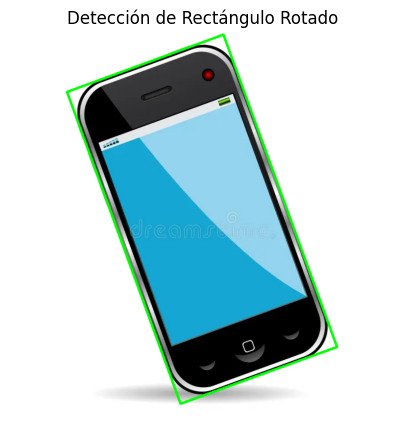

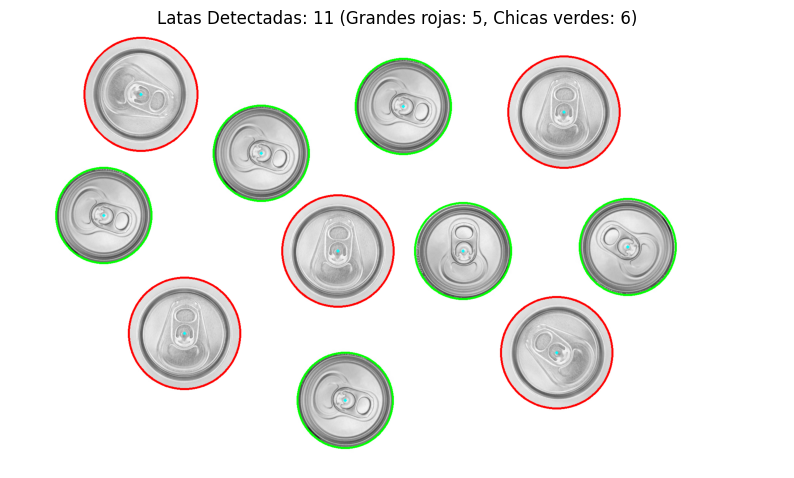

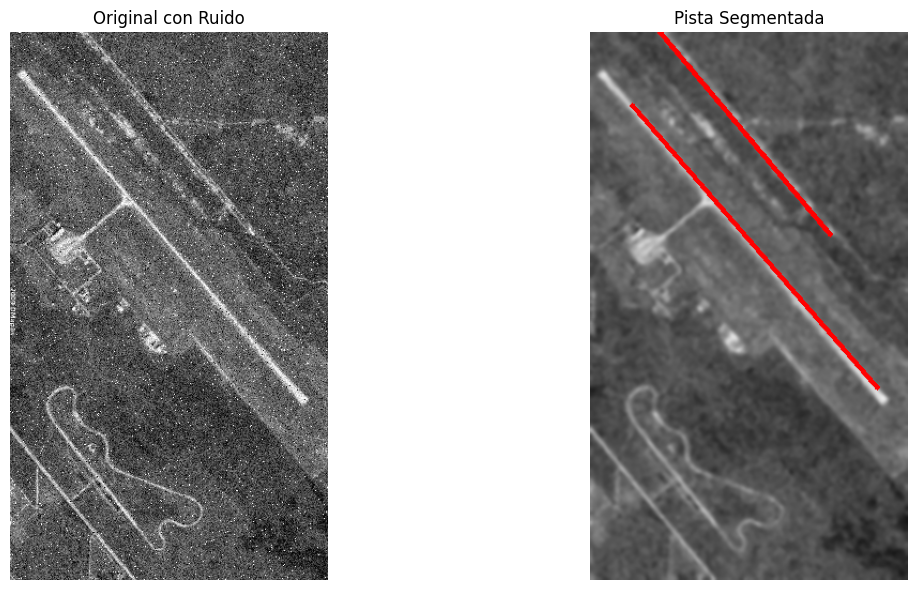

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# EJERCICIO 5.1: DETECCIÓN DE OBJETO RECTANGULAR 
# =====================================================================
def detectar_rectangulo(img_path):
    # Cargar imagen en escala de grises y a color para dibujar
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None: 
        print("Imagen no encontrada")
        return
    img_color = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    
    # Preprocesamiento: Suavizado y Canny
    blur = cv2.GaussianBlur(img, (5, 5), 0)
    bordes = cv2.Canny(blur, 50, 150)
    
    # Encontrar contornos
    contornos, _ = cv2.findContours(bordes, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Buscar el contorno más grande que se aproxime a un rectángulo
    if contornos:
        # Ordenamos los contornos por área (de mayor a menor)
        contornos = sorted(contornos, key=cv2.contourArea, reverse=True)
        
        for c in contornos:
            # Filtro básico para ignorar ruido (usando el área real del contorno)
            if cv2.contourArea(c) > 1000: 
                
                # 1. Encontramos el rectángulo de área mínima (permite rotación)
                rect = cv2.minAreaRect(c)
                
                # 2. Obtenemos las 4 esquinas del rectángulo
                box = cv2.boxPoints(rect)
                box = np.int32(box) # Convertimos las coordenadas a enteros
                
                # 3. Dibujamos el rectángulo usando las 4 esquinas rotadas
                cv2.drawContours(img_color, [box], 0, (0, 255, 0), 3)
                
                break # Solo dibujamos el más grande
                
    plt.figure(figsize=(8, 5))
    plt.imshow(img_color)
    plt.title('Detección de Rectángulo Rotado')
    plt.axis('off')
    plt.show()

# =====================================================================
# EJERCICIO 5.2: TRANSFORMADA DE HOUGH PARA CÍRCULOS
# =====================================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

def analizar_latas(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None: 
        print("Imagen no encontrada. Verificá la ruta.")
        return
    img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    
    # 1. Binarización: Subimos el umbral a 250 para no perder los bordes claros
    _, silueta = cv2.threshold(img, 250, 255, cv2.THRESH_BINARY_INV)
    
    # 2. Morfología: Rellenamos el interior para hacer discos sólidos
    kernel = np.ones((15, 15), np.uint8)
    silueta_solida = cv2.morphologyEx(silueta, cv2.MORPH_CLOSE, kernel)
    
    # Suavizamos un poco el borde del disco
    silueta_blur = cv2.GaussianBlur(silueta_solida, (9, 9), 0)
    
    # 3. Detección
    circulos = cv2.HoughCircles(
        silueta_blur, 
        cv2.HOUGH_GRADIENT, 
        dp=1, 
        minDist=80, 
        param1=50, 
        param2=20,       
        minRadius=50, 
        maxRadius=160    
    )
    
    latas_grandes = 0
    latas_chicas = 0
    
    if circulos is not None:
        circulos = np.uint16(np.around(circulos))
        
        # Umbral dinámico inteligente
        radios = [i[2] for i in circulos[0, :]]
        umbral_radio_dinamico = np.mean(radios)
        
        for i in circulos[0, :]:
            centro = (i[0], i[1])
            radio = i[2]
            
            if radio > umbral_radio_dinamico:
                latas_grandes += 1
                color = (255, 0, 0) # Rojo para Grandes
            else:
                latas_chicas += 1
                color = (0, 255, 0) # Verde para Chicas
                
            # Dibujamos centro y borde
            cv2.circle(img_color, centro, 2, (0, 255, 255), 3)
            cv2.circle(img_color, centro, radio, color, 4)
            
    total = latas_grandes + latas_chicas
    
    plt.figure(figsize=(10, 6))
    plt.imshow(img_color)
    plt.title(f'Latas Detectadas: {total} (Grandes rojas: {latas_grandes}, Chicas verdes: {latas_chicas})')
    plt.axis('off')
    plt.show()

# analizar_latas('latas.jpg')


# =====================================================================
# SEGMENTACIÓN AUTOMÁTICA DE PISTA (VERSIÓN ROBUSTA)
# =====================================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt

def segmentar_pista(img_path):

    # -------------------------------------------------
    # 1. Carga
    # -------------------------------------------------
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print("Imagen no encontrada")
        return

    # -------------------------------------------------
    # 2. Restauración (ruido gaussiano + impulsivo)
    # -------------------------------------------------
    img_med = cv2.medianBlur(img, 5)
    img_rest = cv2.GaussianBlur(img_med, (5,5), 1.5)

    # -------------------------------------------------
    # 3. Canny AUTOMÁTICO (sin valores mágicos)
    # -------------------------------------------------
    v = np.median(img_rest)

    lower = int(max(0, 0.66*v))
    upper = int(min(255, 1.33*v))

    bordes = cv2.Canny(img_rest, lower, upper)

    # -------------------------------------------------
    # 4. Transformada de Hough
    # -------------------------------------------------
    lineas = cv2.HoughLinesP(
        bordes,
        rho=1,
        theta=np.pi/180,
        threshold=80,
        minLineLength=80,
        maxLineGap=20
    )

    img_color = cv2.cvtColor(img_rest, cv2.COLOR_GRAY2RGB)

    if lineas is None:
        print("No se detectaron líneas")
        return

    # -------------------------------------------------
    # 5. Calcular orientación de cada línea
    # -------------------------------------------------
    angulos = []
    datos = []

    for l in lineas:
        x1, y1, x2, y2 = l[0]

        angulo = np.degrees(np.arctan2(y2-y1, x2-x1))
        largo = np.hypot(x2-x1, y2-y1)

        angulos.append(angulo)
        datos.append((x1,y1,x2,y2,angulo,largo))

    angulos = np.array(angulos)

    hist, bins = np.histogram(angulos, bins=36)
    angulo_dom = bins[np.argmax(hist)]

    # -------------------------------------------------
    # 7. Filtrar líneas paralelas a la pista
    # -------------------------------------------------
    tolerancia = 10   # grados

    candidatas = [
        d for d in datos
        if abs(d[4] - angulo_dom) < tolerancia
    ]

    # ordenar por longitud
    candidatas.sort(key=lambda x: x[5], reverse=True)

    # -------------------------------------------------
    # 8. Dibujar las dos más largas
    # -------------------------------------------------
    for linea in candidatas[:2]:
        x1,y1,x2,y2,_,_ = linea
        cv2.line(img_color,(x1,y1),(x2,y2),(255,0,0),4)

    # -------------------------------------------------
    # 9. Mostrar resultados
    # -------------------------------------------------
    plt.figure(figsize=(14,6))

    plt.subplot(1,2,1)
    plt.imshow(img, cmap='gray')
    plt.title("Original con Ruido")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(img_color)
    plt.title("Pista Segmentada")
    plt.axis("off")

    plt.tight_layout()
    plt.show()




detectar_rectangulo('telefono-celular.jpg')
analizar_latas('latas.png')
segmentar_pista('corrientes_ruidogris_rot.jpg')